Saving synthetic_dataset_5000_missing.csv to synthetic_dataset_5000_missing (3).csv
ID          400
Category    400
Price       400
Rating      400
Stock       400
Discount    400
Region      400
Sales       400
dtype: int64
ID          8.0
Category    8.0
Price       8.0
Rating      8.0
Stock       8.0
Discount    8.0
Region      8.0
Sales       8.0
dtype: float64
<bound method DataFrame.info of           ID Category   Price  Rating  Stock  Discount   Region    Sales
0        1.0     Home   46.34     2.0  258.0      34.7   Europe  5185.89
1        2.0   Sports  109.51     1.8  948.0      45.9   Europe  2801.43
2        3.0     Food  377.47     2.4  603.0      36.3  America  2180.05
3        4.0   Sports   30.39     2.9  933.0       3.7   Africa  3023.29
4        5.0   Sports  248.81     2.2  946.0      20.1   Europe  8495.88
...      ...      ...     ...     ...    ...       ...      ...      ...
4995  4996.0     Home  349.77     2.5  239.0      25.4  America  8589.83
4996  4997.0    

/tmp/ipykernel_38096/837740318.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Rating"].fillna(df["Rating"].mean(),inplace=True)
/tmp/ipykernel_38096/837740318.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

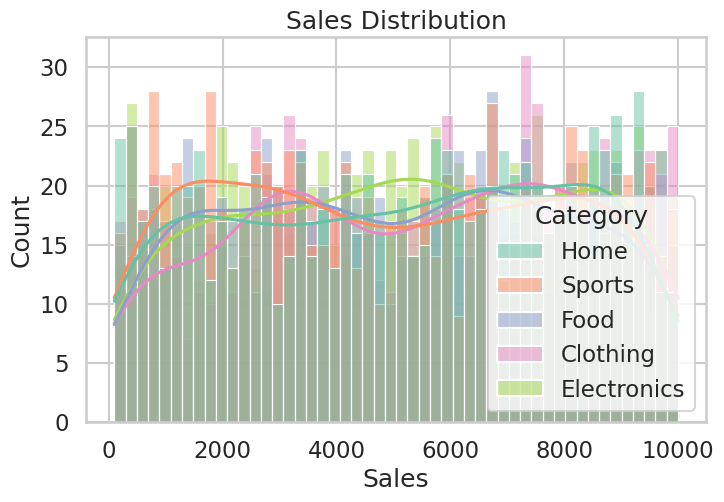

/tmp/ipykernel_38096/837740318.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="Sales", data=df, palette="Set3")


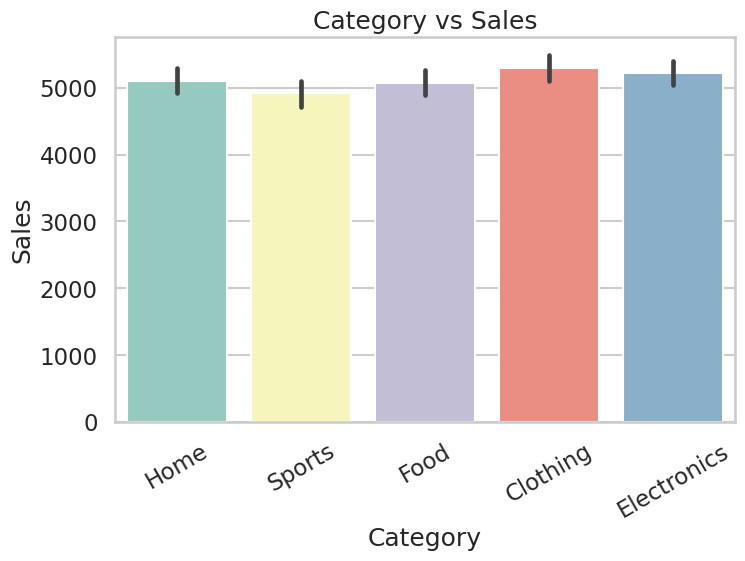

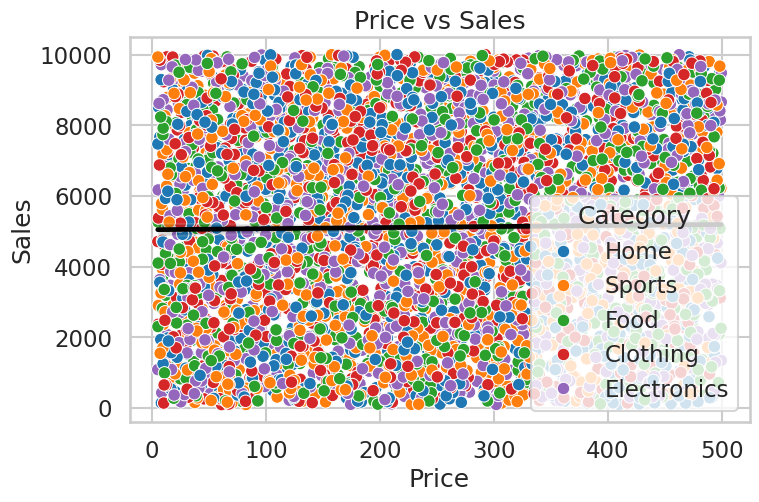

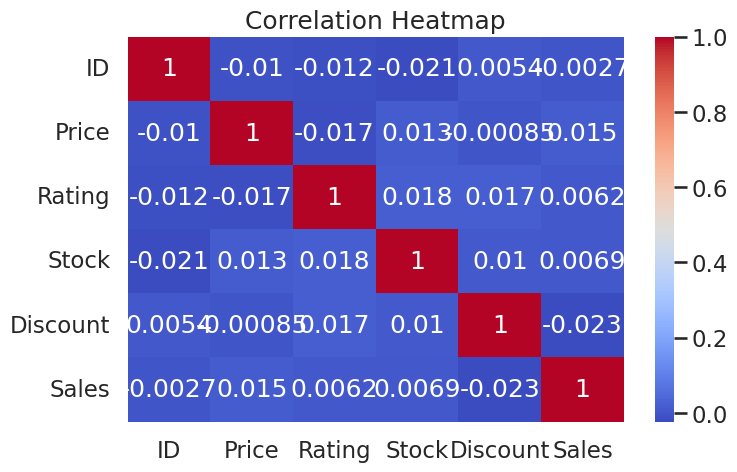

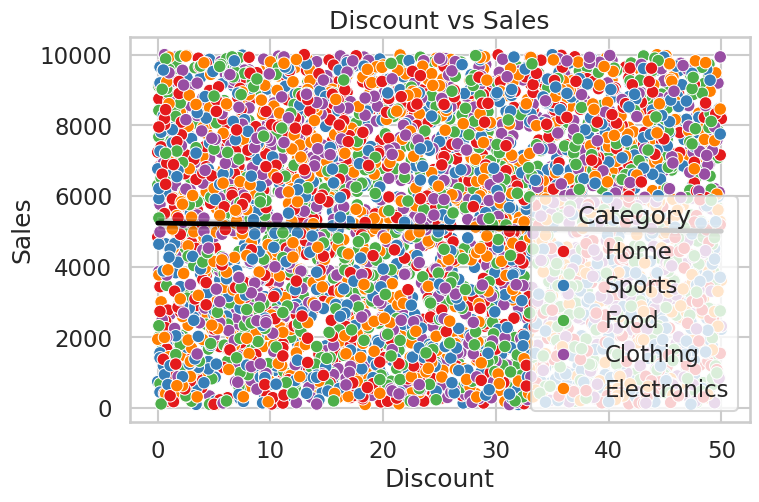

In [ ]:
# Data Cleaning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google. colab import  files
uploaded=files.upload()

df=pd.read_csv("synthetic_dataset_5000_missing.csv")
print(df.isnull().sum())
print((df.isnull().sum()/df.shape[0])*100)
print(df.info)
df_clean=df.dropna(inplace=True)

df["Rating"].fillna(df["Rating"].mean(),inplace=True)
df["Stock"].fillna(df["Stock"].mean(),inplace=True)
df["Discount"].fillna(df["Discount"].mean(),inplace=True)
df["Sales"].fillna(df["Sales"].mean(),inplace=True)
df["Category"].fillna(df["Category"].mode()[0],inplace=True)
df["Region"].fillna(df["Region"].mode()[0],inplace=True)
df.duplicated().sum()
df.drop_duplicates(inplace=True)
df["ID"]=df["ID"].astype(int)
df.isnull()
df.head(40)



# Sales Distribution

plt.figure(figsize=(8,5))

sns.histplot(df, x="Sales", bins=50, kde=True, hue="Category", palette="Set2")

plt.title("Sales Distribution")
plt.show()



# Category vs Sales

plt.figure(figsize=(8,5))

sns.barplot(x="Category", y="Sales", data=df, palette="Set3")

plt.title("Category vs Sales")
plt.xticks(rotation=30)
plt.show()



# Price vs Sales

plt.figure(figsize=(8,5))

sns.scatterplot(x="Price", y="Sales", data=df, hue="Category", palette="tab10")

sns.regplot(x="Price", y="Sales", data=df, scatter=False, color="black")

plt.xlabel("Price")
plt.ylabel("Sales")
plt.title("Price vs Sales")
plt.show()

sns.set_style("whitegrid")
sns.set_context("talk")


# Correlation Heatmap
import seaborn as sns
plt.figure(figsize=(8,5))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


# Discount vs Sales

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Discount",
    y="Sales",
    data=df,
    hue="Category",     # multiple colors
    palette="Set1"
)

# Optional trend line
sns.regplot(
    x="Discount",
    y="Sales",
    data=df,
    scatter=False,
    color="black"
)

plt.title("Discount vs Sales")
plt.show()
